In [478]:
import mofr

In [479]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagRegression_strategy.backtest_class import BacktestLL
from Strategies.LeadLagRegression_strategy.strategy_class import StrategyLL, VolumeClass
from support_functions import calculate_MACD, calculate_lead_lag_triggers, calculate_regression_model_price
tol=(1e-1)/2

import seaborn as sns


In [480]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_tree
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [481]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [482]:
import warnings
warnings.filterwarnings('ignore')

In [483]:
max_secs_between_trades=60
cluster_trade_num_threshold=5
min_price_movement=0.05

burnout_period=30
stop_profit=0.3
makeagg_ratio=0.6

take_profit=0.5
stop_loss=-0.4

br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

In [484]:
##########################
param_dict = {}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

param_dict['br_fee'] = br_fee
##########################


strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.param_dict=param_dict

# Data preparation

In [485]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_ttf_mar_apr.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem1_oot_mar_apr.csv',
                    parse_dates=['datetime']).reset_index()

In [486]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [487]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [488]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [489]:
data_lag['date']=data_lag['datetime'].apply(lambda x: x.date())

In [490]:
data_lag=calculate_MACD(data_lag)
data_lag=calculate_lead_lag_triggers(data_lead, data_lag, max_secs_between_trades, cluster_trade_num_threshold, min_price_movement)
data_lag=calculate_regression_model_price(data_lead, data_lag, 10, 10, 5)

In [491]:
def calc_time_since_predicted_price(row):
    
        return (row['datetime']-row['lag_price_predicted_datetime']).total_seconds()
   

In [492]:
 data_lag['time_since_predicted_price']=data_lag[['datetime', 'lag_price_predicted_datetime']].apply(lambda row: calc_time_since_predicted_price(row), axis=1)

In [493]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff,date,MACD,trigger_datetime,trigger_action,lag_price_predicted,lag_price_predicted_datetime,time_since_predicted_price
0,538,2024-03-01 09:00:00.000000000,NaN,NaN,56.41,56.61,56.510,1,2.00000,2024-03-01,NaN,NaT,NaN,NaN,NaT,NaN
1,539,2024-03-01 09:00:05.000000000,NaN,NaN,56.41,56.62,56.515,1,5.00000,2024-03-01,NaN,NaT,NaN,NaN,NaT,NaN
2,540,2024-03-01 09:00:09.000000000,NaN,NaN,56.41,56.61,56.510,1,4.00000,2024-03-01,NaN,NaT,NaN,NaN,NaT,NaN
3,541,2024-03-01 09:00:09.338750124,56.41,2.0,56.41,56.61,56.510,0,0.33875,2024-03-01,0.0,NaT,NaN,NaN,NaT,NaN
4,542,2024-03-01 09:00:10.000000000,NaN,NaN,56.29,56.61,56.450,1,0.66125,2024-03-01,0.0,NaT,NaN,NaN,NaT,NaN


# Target Calculation

In [494]:
def calculate_close_slot_long(open_price, open_time, row):
    
        if row['ask_price']-row['bid_price']>param_dict['ba_max']:
            return (0,0)
    
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        
        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=1
        
        return strategy_class.calculate_close_slot()
    
def calculate_close_slot_short(open_price, open_time, row):

        if row['ask_price']-row['bid_price']>param_dict['ba_max']:
            return (0,0)
        
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        
        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=-1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=-1
        
        return strategy_class.calculate_close_slot()

    
def calculate_profit_long(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['ask_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_long(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return price-open_price-2*param_dict['br_fee']
    
    return 0

def calculate_profit_short(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['bid_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_short(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return open_price-price-2*param_dict['br_fee']
    
    return 0

In [495]:
df_filtered=data_lag[data_lag['time_since_predicted_price']<data_lag['time_diff']]

In [496]:
for date in sorted(list(set(df_filtered.date))):
    print(date)
    a=data_lag[data_lag['date']==date]
    df_filtered.loc[df_filtered['date']==date, 'profit_long']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_long(row, a), axis=1)
    df_filtered.loc[df_filtered['date']==date, 'profit_short']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_short(row, a), axis=1)

2024-03-01
2024-03-04
2024-03-05
2024-03-06
2024-03-07
2024-03-08
2024-03-11
2024-03-12
2024-03-13
2024-03-14
2024-03-15
2024-03-18
2024-03-19
2024-03-20
2024-03-21
2024-03-22
2024-03-25
2024-03-26
2024-03-27
2024-03-28
2024-04-02
2024-04-03
2024-04-04
2024-04-05
2024-04-08
2024-04-09
2024-04-10
2024-04-11
2024-04-12
2024-04-15
2024-04-16
2024-04-17
2024-04-18
2024-04-19
2024-04-22
2024-04-23
2024-04-24
2024-04-25
2024-04-26
2024-04-29
2024-04-30


In [497]:
df_filtered=df_filtered[df_filtered['datetime'].apply(lambda x: x.hour>8 and  x.hour<17)]
df_filtered=df_filtered[df_filtered['datetime'].apply(lambda x: x.day!=10 or x.month==3)]

In [498]:
df_filtered.to_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem1_mar_apr_enriched.csv')

# Model Calculation

In [499]:
seed=2

In [500]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import r2_score

## Long model 

In [501]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['ask_price']

In [502]:
fil1=df_filtered['MACD'].isnull()==False
fil2=df_filtered['price_diff'].isnull()==False
fil3=df_filtered['trigger_action'].isnull()==False
fil4=df_filtered['profit_long'].isnull()==False

In [503]:
df_modelling=df_filtered[fil1&fil2&fil3&fil4]

### Regression

In [504]:
# Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
X_train = df_modelling[['MACD', 'price_diff', 'trigger_action']]
y_train = df_modelling['profit_long'].fillna(0)

# Add a constant to the independent variable
X_train = sm.add_constant(X_train)

# Fit the model using statsmodels
model = sm.OLS(y_train, X_train).fit()

# Predict the lag_log_ret for the current day using the model
# X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
# r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

# Optionally, print the summary for each model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            profit_long   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     17.59
Date:                Tue, 06 Aug 2024   Prob (F-statistic):           2.32e-11
Time:                        11:36:57   Log-Likelihood:                -2028.1
No. Observations:                5268   AIC:                             4064.
Df Residuals:                    5264   BIC:                             4090.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0804      0.006    -14.

### XGBoost

In [505]:
df_modelling['y']=(df_modelling['profit_long']>0).apply(int)
df_modelling['y'].value_counts()

y
0    3281
1    1987
Name: count, dtype: int64

In [506]:
feature_cols=['MACD', 'price_diff', 'trigger_action']

In [507]:
X_train, X_test, y_train, y_test = train_test_split(df_modelling[feature_cols], df_modelling['y'], test_size=0.25, random_state=seed)

xgb_model = XGBClassifier(max_depth=3, gamma=1, min_child_weight=5, n_estimators=5)
xgb_model.fit(X_train,
              y_train)
df_modelling['XGB_SCORE']=xgb_model.predict_proba(df_modelling[feature_cols])[:, 1]
X_train['XGB_SCORE']=xgb_model.predict_proba(X_train[feature_cols])[:, 1]
X_test['XGB_SCORE']=xgb_model.predict_proba(X_test[feature_cols])[:, 1]

preds_ = xgb_model.predict_proba(X_test[feature_cols])

In [508]:
print('The Lift on the df set is: '+ str(mofr.metrics.lift(y_train, X_train['XGB_SCORE'])))
print('The gini on the df set is: '+ str(mofr.metrics.gini(y_train, X_train['XGB_SCORE'])))
print('The accuracy on the df set is: '+ str(mofr.metrics.accuracy_score(y_train, X_train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(y_test, X_test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(y_test, X_test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(y_test, X_test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the df set is: 1.4769099649369388
The gini on the df set is: 0.22921790793889296
The accuracy on the df set is: 0.6279422930903569


The Lift on the test set is: 1.1348361079516078
The gini on the test set is: 0.09655167383143026
The accuracy on the test set is: 0.6165527714502658




In [509]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD,0.052863
1,price_diff,0.056287
2,trigger_action,-0.004490


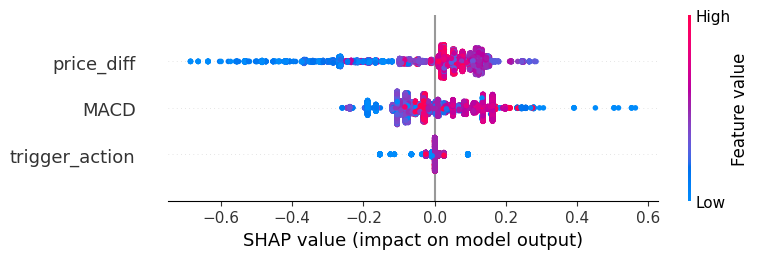

In [510]:
import shap
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_modelling[feature_cols])
shap.summary_plot(shap_values, df_modelling[feature_cols])
plt.show()

#### **Precision curve**

In [511]:
preds_p = xgb_model.predict_proba(X_test[feature_cols])[:, 1]
#preds_p = model.predict(X_test).apply(lambda x: 1/(1+np.exp(-x)))

# threshold for more certainty in predicted values
thold_list = np.arange(0.2, 0.4, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [1 if x > thold else 0 for x in preds_p]
    cm = confusion_matrix(y_test, preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [512]:
prec_recall_df[-50:]

,thold,precision,recall,count
250,0.450,0.590909,0.025540,22
251,0.451,0.590909,0.025540,22
252,0.452,0.631579,0.023576,19
253,0.453,0.600000,0.017682,15
254,0.454,0.600000,0.017682,15
255,0.455,0.600000,0.017682,15
256,0.456,0.600000,0.017682,15
257,0.457,0.600000,0.017682,15
258,0.458,0.600000,0.017682,15
259,0.459,0.600000,0.017682,15


### Interactions

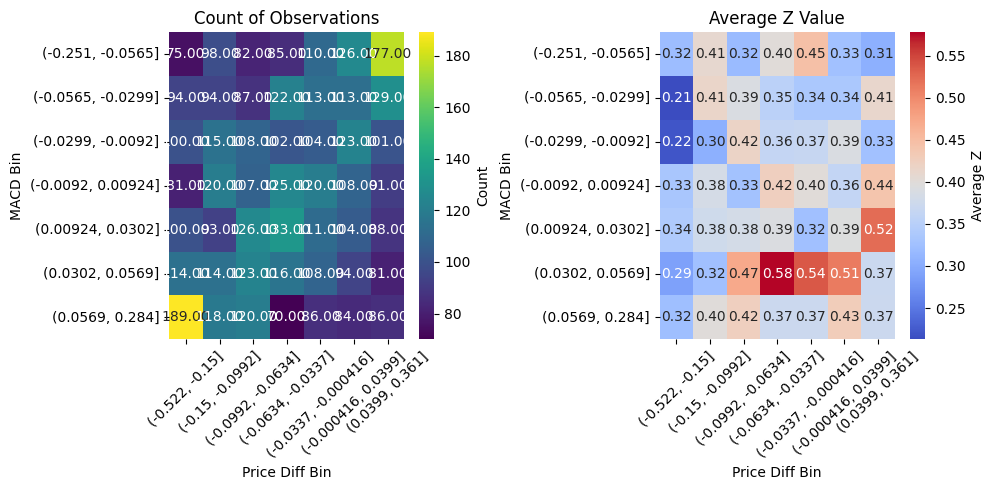

In [513]:
# Binning with interval labels
df_modelling.loc[:,'MACD_bin'] = pd.qcut(df_modelling['MACD'], 7, retbins=False, precision=3)
df_modelling.loc[:,'price_diff_bin'] = pd.qcut(df_modelling['price_diff'], 7, retbins=False, precision=3)


# Create pivot tables
count_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='count')
mean_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='mean')

# Setup figure for heatmaps
plt.figure(figsize=(10,5))

# Heatmap for count of observations
plt.subplot(1, 2, 1)
sns.heatmap(count_pivot, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Count'})
plt.title('Count of Observations')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(count_pivot.columns)) + 0.5, count_pivot.columns, rotation=45)
plt.yticks(np.arange(len(count_pivot.index)) + 0.5, count_pivot.index, rotation=0)

# Heatmap for average of Z
plt.subplot(1, 2, 2)
sns.heatmap(mean_pivot, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Average Z'})
plt.title('Average Z Value')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(mean_pivot.columns)) + 0.5, mean_pivot.columns, rotation=45)
plt.yticks(np.arange(len(mean_pivot.index)) + 0.5, mean_pivot.index, rotation=0)

plt.tight_layout()
plt.show()

In [514]:
count_pivot

price_diff_bin,"(-0.522, -0.15]","(-0.15, -0.0992]","(-0.0992, -0.0634]","(-0.0634, -0.0337]","(-0.0337, -0.000416]","(-0.000416, 0.0399]","(0.0399, 0.361]"
MACD_bin,,,,,,,
"(-0.251, -0.0565]",75,98,82,85,110,126,177
"(-0.0565, -0.0299]",94,94,87,122,113,113,129
"(-0.0299, -0.0092]",100,115,108,102,104,123,101
"(-0.0092, 0.00924]",81,120,107,125,120,108,91
"(0.00924, 0.0302]",100,93,126,133,111,104,88
"(0.0302, 0.0569]",114,114,123,116,108,94,81
"(0.0569, 0.284]",189,118,120,70,86,84,86


In [515]:
mean_pivot

price_diff_bin,"(-0.522, -0.15]","(-0.15, -0.0992]","(-0.0992, -0.0634]","(-0.0634, -0.0337]","(-0.0337, -0.000416]","(-0.000416, 0.0399]","(0.0399, 0.361]"
MACD_bin,,,,,,,
"(-0.251, -0.0565]",0.320000,0.408163,0.317073,0.400000,0.445455,0.325397,0.305085
"(-0.0565, -0.0299]",0.212766,0.414894,0.390805,0.352459,0.336283,0.336283,0.410853
"(-0.0299, -0.0092]",0.220000,0.304348,0.416667,0.362745,0.365385,0.390244,0.326733
"(-0.0092, 0.00924]",0.333333,0.383333,0.327103,0.424000,0.400000,0.361111,0.439560
"(0.00924, 0.0302]",0.340000,0.376344,0.380952,0.390977,0.324324,0.394231,0.522727
"(0.0302, 0.0569]",0.289474,0.324561,0.471545,0.577586,0.537037,0.510638,0.370370
"(0.0569, 0.284]",0.322751,0.398305,0.425000,0.371429,0.372093,0.428571,0.372093


## Short model 

In [516]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['bid_price']

In [517]:
fil1=df_filtered['MACD'].isnull()==False
fil2=df_filtered['price_diff'].isnull()==False
fil3=df_filtered['trigger_action'].isnull()==False
fil4=df_filtered['profit_long'].isnull()==False

In [518]:
df_modelling=df_filtered[fil1&fil2&fil3&fil4]

In [519]:
# Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
X_train = df_modelling[['MACD', 'price_diff', 'trigger_action']]
y_train = df_modelling['profit_short'].fillna(0)

# Add a constant to the independent variable
X_train = sm.add_constant(X_train)

# Fit the model using statsmodels
model = sm.OLS(y_train, X_train).fit()

# Predict the lag_log_ret for the current day using the model
# X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
# r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

# Optionally, print the summary for each model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           profit_short   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     36.34
Date:                Tue, 06 Aug 2024   Prob (F-statistic):           3.09e-23
Time:                        11:37:01   Log-Likelihood:                -1936.7
No. Observations:                5268   AIC:                             3881.
Df Residuals:                    5264   BIC:                             3908.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0927      0.005    -17.

### XGBoost

In [520]:
df_modelling['y']=(df_modelling['profit_short']>0).apply(int)
df_modelling['y'].value_counts()

y
0    3371
1    1897
Name: count, dtype: int64

In [521]:
feature_cols=['MACD', 'price_diff', 'trigger_action']

In [522]:
X_train, X_test, y_train, y_test = train_test_split(df_modelling[feature_cols], df_modelling['y'], test_size=0.25, random_state=seed)

xgb_model = XGBClassifier(max_depth=3, gamma=1, min_child_weight=5, n_estimators=5)
xgb_model.fit(X_train,
              y_train)
df_modelling['XGB_SCORE']=xgb_model.predict_proba(df_modelling[feature_cols])[:, 1]
X_train['XGB_SCORE']=xgb_model.predict_proba(X_train[feature_cols])[:, 1]
X_test['XGB_SCORE']=xgb_model.predict_proba(X_test[feature_cols])[:, 1]

preds_ = xgb_model.predict_proba(X_test[feature_cols])

In [523]:
print('The Lift on the df set is: '+ str(mofr.metrics.lift(y_train, X_train['XGB_SCORE'])))
print('The gini on the df set is: '+ str(mofr.metrics.gini(y_train, X_train['XGB_SCORE'])))
print('The accuracy on the df set is: '+ str(mofr.metrics.accuracy_score(y_train, X_train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(y_test, X_test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(y_test, X_test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(y_test, X_test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the df set is: 1.643575369123922
The gini on the df set is: 0.24637493130173937
The accuracy on the df set is: 0.6522399392558846


The Lift on the test set is: 1.5680617171189979
The gini on the test set is: 0.2404522149864725
The accuracy on the test set is: 0.6408504176157934




In [524]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD,-0.108923
1,price_diff,-0.080034
2,trigger_action,-0.028866


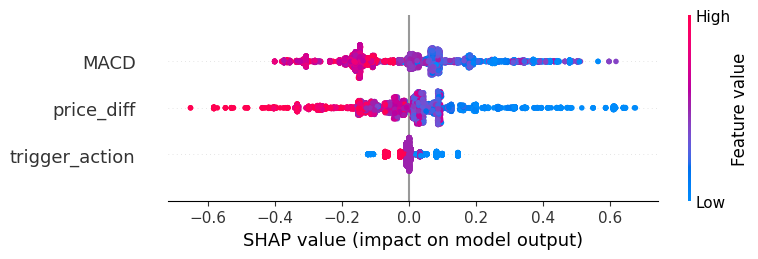

In [525]:
import shap
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_modelling[feature_cols])
shap.summary_plot(shap_values, df_modelling[feature_cols])
plt.show()

#### **Precision curve**

In [526]:
preds_p = xgb_model.predict_proba(X_test[feature_cols])[:, 1]
#preds_p = model.predict(X_test).apply(lambda x: 1/(1+np.exp(-x)))

# threshold for more certainty in predicted values
thold_list = np.arange(0.2, 0.55, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [1 if x > thold else 0 for x in preds_p]
    cm = confusion_matrix(y_test, preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [527]:
prec_recall_df[-50:]

,thold,precision,recall,count
300,0.500,0.625000,0.031315,24
301,0.501,0.625000,0.031315,24
302,0.502,0.625000,0.031315,24
303,0.503,0.625000,0.031315,24
304,0.504,0.625000,0.031315,24
305,0.505,0.625000,0.031315,24
306,0.506,0.625000,0.031315,24
307,0.507,0.625000,0.031315,24
308,0.508,0.625000,0.031315,24
309,0.509,0.625000,0.031315,24


### Interactions

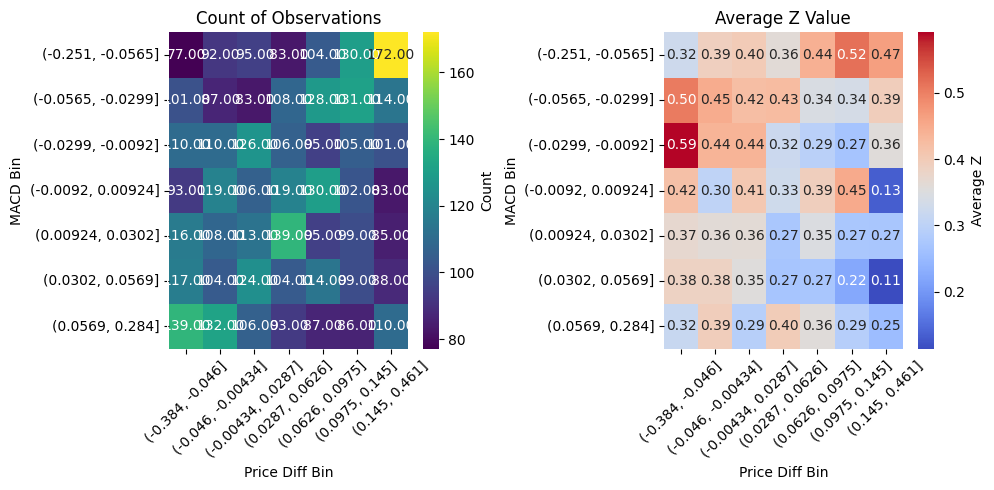

In [528]:
# Binning with interval labels
df_modelling.loc[:,'MACD_bin'] = pd.qcut(df_modelling['MACD'], 7, retbins=False, precision=3)
df_modelling.loc[:,'price_diff_bin'] = pd.qcut(df_modelling['price_diff'], 7, retbins=False, precision=3)


# Create pivot tables
count_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='count')
mean_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='mean')

# Setup figure for heatmaps
plt.figure(figsize=(10,5))

# Heatmap for count of observations
plt.subplot(1, 2, 1)
sns.heatmap(count_pivot, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Count'})
plt.title('Count of Observations')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(count_pivot.columns)) + 0.5, count_pivot.columns, rotation=45)
plt.yticks(np.arange(len(count_pivot.index)) + 0.5, count_pivot.index, rotation=0)

# Heatmap for average of Z
plt.subplot(1, 2, 2)
sns.heatmap(mean_pivot, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Average Z'})
plt.title('Average Z Value')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(mean_pivot.columns)) + 0.5, mean_pivot.columns, rotation=45)
plt.yticks(np.arange(len(mean_pivot.index)) + 0.5, mean_pivot.index, rotation=0)

plt.tight_layout()
plt.show()

In [529]:
count_pivot

price_diff_bin,"(-0.384, -0.046]","(-0.046, -0.00434]","(-0.00434, 0.0287]","(0.0287, 0.0626]","(0.0626, 0.0975]","(0.0975, 0.145]","(0.145, 0.461]"
MACD_bin,,,,,,,
"(-0.251, -0.0565]",77,92,95,83,104,130,172
"(-0.0565, -0.0299]",101,87,83,108,128,131,114
"(-0.0299, -0.0092]",110,110,126,106,95,105,101
"(-0.0092, 0.00924]",93,119,106,119,130,102,83
"(0.00924, 0.0302]",116,108,113,139,95,99,85
"(0.0302, 0.0569]",117,104,124,104,114,99,88
"(0.0569, 0.284]",139,132,106,93,87,86,110


In [530]:
mean_pivot

price_diff_bin,"(-0.384, -0.046]","(-0.046, -0.00434]","(-0.00434, 0.0287]","(0.0287, 0.0626]","(0.0626, 0.0975]","(0.0975, 0.145]","(0.145, 0.461]"
MACD_bin,,,,,,,
"(-0.251, -0.0565]",0.324675,0.391304,0.400000,0.361446,0.442308,0.515385,0.465116
"(-0.0565, -0.0299]",0.504950,0.448276,0.421687,0.425926,0.343750,0.335878,0.394737
"(-0.0299, -0.0092]",0.590909,0.436364,0.436508,0.320755,0.294737,0.266667,0.356436
"(-0.0092, 0.00924]",0.419355,0.302521,0.405660,0.327731,0.392308,0.450980,0.132530
"(0.00924, 0.0302]",0.370690,0.361111,0.362832,0.273381,0.347368,0.272727,0.270588
"(0.0302, 0.0569]",0.384615,0.384615,0.354839,0.269231,0.271930,0.222222,0.113636
"(0.0569, 0.284]",0.316547,0.393939,0.292453,0.397849,0.356322,0.290698,0.254545
